[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sheik-info/gnn_project/blob/master/predict_link.ipynb)

**sujet du projet dnn:**


Prédiction de liens : En cachant certains liens, peut-on parvenir à les redécouvrir? Ce problème peut être évalué classiquement en utilisant l'AUC, Average Precision, Hits@k et MRR.

In [49]:
!pip install torch_geometric
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    roc_auc_score,
)

In [50]:
G = nx.read_graphml("airportsAndCoordAndPop.graphml")
#nx.draw(G, node_size=15)

In [51]:
data = from_networkx(G)


In [52]:
print(data)
print(data.keys())
print(data['edge_index'].shape)

Data(edge_index=[2, 27094], lon=[3363], lat=[3363], population=[3363], country=[3363], city_name=[3363], num_nodes=3363)
['lon', 'population', 'country', 'edge_index', 'num_nodes', 'lat', 'city_name']
torch.Size([2, 27094])


In [53]:
#on va essayer de deviner les noeuds des pays qui ont été supprimés
#on encode ce qu'on veut avoir en sortie y, ce qu'on veut deviner
encoder1 = LabelEncoder()
integer_labels = encoder1.fit_transform(data.country)
target_tensor1 = th.tensor(integer_labels, dtype=th.long)
print("target_tensor: ", target_tensor1)
data.y = target_tensor1
data.num_classes = len(set(data.country))

target_tensor:  tensor([ 66,  66,  66,  ...,  33, 143, 143])


In [54]:
encoder2 = LabelEncoder()
integer_labels = encoder2.fit_transform(data.country)
target_tensor1 = th.tensor(integer_labels, dtype=th.float).unsqueeze(1)
print(data)
#data.x = th.cat([data.x, target_tensor1], dim=1)
data.x = target_tensor1
data.num_classes = len(set(data.country))

Data(edge_index=[2, 27094], lon=[3363], lat=[3363], population=[3363], country=[3363], city_name=[3363], num_nodes=3363, y=[3363], num_classes=212)


In [55]:
# encoder2 = LabelEncoder()
# integer_labels = encoder2.fit_transform(data.city_name)
# target_tensor2 = th.tensor(integer_labels, dtype=th.long)
# print("target_tensor: ", target_tensor2)
# data.y = target_tensor2
# data.num_classes = len(set(data.city_name))

On va utiliser le VGAE pour faire de la prédictiion de liens

In [56]:
#préparation des données
#transformation des degrés en radian avec pytorch
lat, lon = th.deg2rad(data.lat.float()), th.deg2rad(data.lon.float())
#ref city hunter
xyz = th.stack([th.cos(lat)*th.cos(lon), th.cos(lat)*th.sin(lon), th.sin(lat)], 1)
#normalisation des données
log = th.log10(data.population.float()).unsqueeze(1)
log = (log - log.mean()) / log.std()
#encodage one hot
country = F.one_hot(data.y, data.num_classes).float()

data.x = th.cat([xyz, log, country], dim=1)
#est non dirigé donc on a pas besoin de val_vgae mais on est obligé de le garder
#linksplit indispensable pour la prédiction de liens
train_vgae, val_vgae, test_vgae = RandomLinkSplit(is_undirected=True)(data)

In [57]:

device = th.device('cuda' if th.cuda.is_available() else 'cpu')

pos_edge_index = getattr(train_vgae, 'pos_edge_label_index', train_vgae.edge_label_index[:, train_vgae.edge_label == 1]).to(device)

class Encoder(nn.Module):
  def __init__(self, dim_in, dim_out):
    super().__init__()
    self.conv1 = GCNConv(dim_in, 2 * dim_out)
    self.conv2 = GCNConv(2 * dim_out,2 * dim_out)
    self.conv3 = GCNConv(2 * dim_out,2 * dim_out)
    self.conv_mu = GCNConv(2 * dim_out, dim_out)
    self.conv_logstd = GCNConv(2 * dim_out, dim_out)

  def forward(self, x, edge_index):
    x = self.conv1(x, edge_index).relu()
    x = self.conv2(x, edge_index).relu()
    x = self.conv3(x, edge_index).relu()
    return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

def train(model, data, epochs):
    model.train()
    optimizer.zero_grad()
    z = model.encode(train_vgae.x, train_vgae.edge_index)
    loss = model.recon_loss(z, pos_edge_index) + (1 / train_vgae.num_nodes) * model.kl_loss()
    loss.backward()
    #utilise le backward pour optimiser les parametres
    optimizer.step()

    return float(loss),

In [58]:
#chosis le hardware à utiliser cuda si c'est disponible sinon cpu
device = th.device('cuda' if th.cuda.is_available() else 'cpu')
model = VGAE(Encoder(data.num_features, 16)).to(device)
optimizer = th.optim.Adam(model.parameters(), lr=0.001)

Début de l'entraînement du modèle VGAE...
Epoch: 001, Train Loss: 3.4229, Val Loss: 1.3511
Epoch: 100, Train Loss: 1.0411, Val Loss: 1.0396
Epoch: 200, Train Loss: 0.8935, Val Loss: 0.8887
Epoch: 300, Train Loss: 0.8746, Val Loss: 0.9054
Epoch: 400, Train Loss: 0.8663, Val Loss: 0.9018
Epoch: 500, Train Loss: 0.8617, Val Loss: 0.9097
Epoch: 600, Train Loss: 0.8585, Val Loss: 0.8737
Epoch: 700, Train Loss: 0.8445, Val Loss: 0.8644
Epoch: 800, Train Loss: 0.8338, Val Loss: 0.8437
Epoch: 900, Train Loss: 0.8256, Val Loss: 0.8367
Epoch: 1000, Train Loss: 0.8266, Val Loss: 0.8148
Epoch: 1100, Train Loss: 0.8252, Val Loss: 0.8401
Epoch: 1200, Train Loss: 0.8219, Val Loss: 0.8396
Epoch: 1300, Train Loss: 0.8241, Val Loss: 0.8458
Epoch: 1400, Train Loss: 0.8124, Val Loss: 0.8565
Epoch: 1500, Train Loss: 0.8322, Val Loss: 0.8714
Epoch: 1600, Train Loss: 0.8095, Val Loss: 0.8684
Epoch: 1700, Train Loss: 0.8131, Val Loss: 0.8238
Epoch: 1800, Train Loss: 0.8108, Val Loss: 0.8410
Epoch: 1900, Train

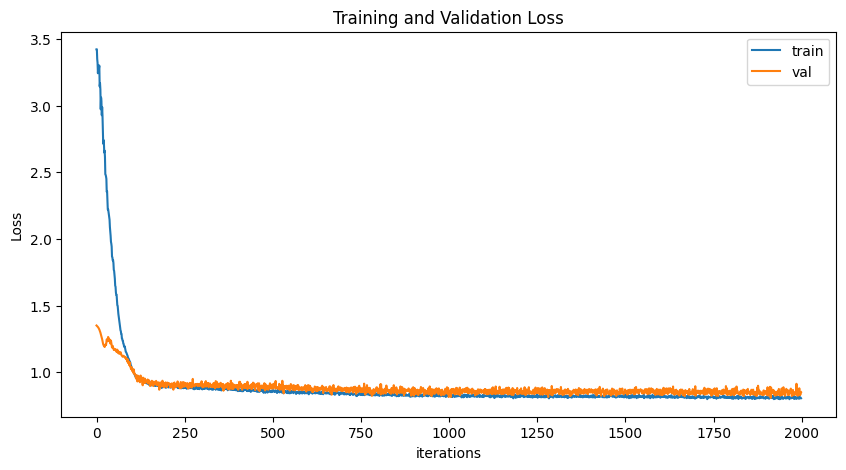

In [59]:
# Nouvelle cellule pour ENTRAÎNER le modèle VGAE (Étape c)
# Sans cette étape, le modèle génère des probabilités totalement aléatoires.
#import matplotlib.pyplot as plt

# On s'assure d'avoir la variable train_data pour la fonction train définie plus haut
train_data = train_vgae.to(device)

val_losses = []
train_losses = []
print("Début de l'entraînement du modèle VGAE...")
for epoch in range(1, 2000):
    # 1. Entraînement et récupération de la perte d'entraînement
    loss = train(model, train_data, epoch)
    train_loss_val = loss[0]
    train_losses.append(train_loss_val)

    # 2. Évaluation sur le jeu de validation pour calculer la perte de validation
    model.eval()
    with th.no_grad():
        z_val = model.encode(val_vgae.x.to(device), val_vgae.edge_index.to(device))
        # Récupération des arêtes de validation positives
        val_pos_edge = getattr(val_vgae, 'pos_edge_label_index', val_vgae.edge_label_index[:, val_vgae.edge_label == 1]).to(device)
        val_loss_val = model.recon_loss(z_val, val_pos_edge) + (1 / val_vgae.num_nodes) * model.kl_loss()
        val_losses.append(float(val_loss_val))

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch: {epoch:03d}, Train Loss: {train_loss_val:.4f}, Val Loss: {float(val_loss_val):.4f}")

print("Entraînement terminé !")

plt.figure(figsize=(10,5))
plt.title("Training and Validation Loss")
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [60]:
# Encoder les nœuds
z = model.encode(train_vgae.x.to(device), train_vgae.edge_index.to(device))

# Récupérer les indices d'arêtes de test (positives et négatives)
# S'assurer d'utiliser les bons attributs générés par le split
pos_edge_index = getattr(test_vgae, 'pos_edge_label_index', test_vgae.edge_label_index[:, test_vgae.edge_label == 1]).to(device)
neg_edge_index = getattr(test_vgae, 'neg_edge_label_index', test_vgae.edge_label_index[:, test_vgae.edge_label == 0]).to(device)

model.test(z, pos_edge_index, neg_edge_index)

(np.float64(0.9768279885717882), np.float64(0.9793345501504713))

In [61]:
#Check if it is able to reconstruct the original graph, by applying the dot product between
# node vectors. You can do it with something like:
pred_scores = th.sigmoid((z[pos_edge_index[0]] * z[pos_edge_index[1]]).sum(dim=1)).detach().numpy()

# how many edge are predicted with a score upon 0.5 ?
pred_demi = pred_scores > 0.5
print("Nombre d'arêtes prédites avec un score > 0.5 :", pred_demi.sum())

Nombre d'arêtes prédites avec un score > 0.5 : 2675


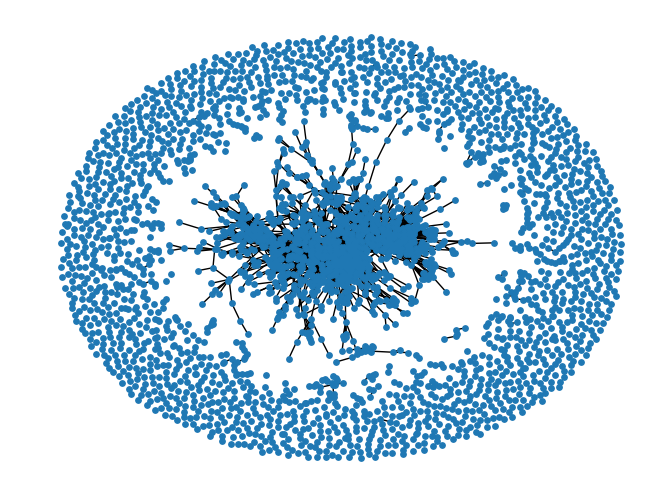

In [62]:
test_vgae.edge_index = pos_edge_index
new_G = to_networkx(test_vgae, to_undirected=True)

nx.draw(new_G, node_size=15)

In [63]:
# 1. Rassembler toutes les arêtes de test (positives et négatives)
test_edges = th.cat([pos_edge_index, neg_edge_index], dim=-1)

# 2. Calculer les prédictions (scores de probabilité) pour toutes ces arêtes
pred_scores_all = th.sigmoid((z[test_edges[0]] * z[test_edges[1]]).sum(dim=1)).detach().cpu().numpy()

# 3. Récupérer les vraies étiquettes de ces liens (1 pour positif, 0 pour négatif)
test_targets = test_vgae.edge_label.cpu().numpy()

# 4. Binariser les prédictions (seuil à 0.5)
pred_labels = (pred_scores_all > 0.5).astype(int)

# 5. Calculer le score de précision
pre_sc = precision_score(test_targets, pred_labels)
print("Precision Score:", pre_sc)

Precision Score: 0.7322748425951273
